In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os as os

path="/media/nicolascatz/ssdcalcul/Projets/M1_NEURO_APP_NC"
path="D:/DATA/Projets/M1_NEURO_APP_NC"

pathdata=path+"/data/UNITS/"
pathresults=path+"/out/"
pathscripts=path+"/scripts/"

print("nombre de fichiers ", ":", len(os.listdir(pathdata)))

files=os.listdir(pathdata)


nombre de fichiers  : 918


In [ ]:
import pandas as pd 


UnitAll=[]
FileAll=[]

for nfile in range(len(files)):
        
    data=sio.loadmat(pathdata+files[nfile])
    single_unit_aligned_sorted=data['single_unit_aligned_sorted']
    Waveform=data['wave_unit']
    block=data['block']
    list_trial_name=data['list_trial_name']

    UnitAligned=single_unit_aligned_sorted[:,:300]
    n_all_cond=data['n_all_cond']



    print('_______________________________________')
    print(files[nfile])
    print('list_trial_name:', list_trial_name)
    print('n_all_cond:', n_all_cond)

    StimCond=[]
    for i in range(len(list_trial_name[0])):
        b=list_trial_name[0,i][0]
        if 'T' in b:
            parties = b.split('_')
            valeur_ms= parties[2]  
            if valeur_ms == '0':
                StimCond.append(int(b[1:2])+1)
            else: 
                StimCond.append(int(b[1])+1)
        elif 'A' in b:
            StimCond.append(int(b[1])+1)
        elif 'F' in b:
            StimCond.append(int(b[1])+1)

    n_all_cond_list=n_all_cond.tolist()
    n_all_cond_list=n_all_cond_list[0]

    print(StimCond)
    StimList=[0]*n_all_cond_list[-1]
    print(n_all_cond_list)

    for i in range(1,len(list_trial_name[0])+1):
        # print(n_all_cond_list[i-1])
        for trial in range(n_all_cond_list[i-1], n_all_cond_list[i]):
            StimList[trial]=StimCond[i-1]

    Unit=UnitAligned.tolist()
    type(StimList)
    UnitDf=pd.DataFrame(Unit)
    UnitDf['Stim']=StimList
    # Column to move
    column_name = 'Stim'
    # Get the list of columns
    cols =  UnitDf.columns.tolist()
    # Remove the column from the list
    cols.remove(column_name)
    # Insert the column at the beginning (position 0)
    cols.insert(0, column_name)
    UnitDf = UnitDf[cols]
    Unit_sorted = UnitDf.sort_values(by=UnitDf.columns[0], ascending=True)
    UnitVal=Unit_sorted.values

    FileAll.append(files[nfile])
    UnitAll.append(UnitVal)


_______________________________________
RAT10-005-01_unit_11a_MERGED.mat
list_trial_name: [[array(['A1_2_100_20ms'], dtype='<U13')
  array(['A1_2_120_20ms'], dtype='<U13')
  array(['A2_2_100_20ms'], dtype='<U13')
  array(['A2_2_120_20ms'], dtype='<U13')
  array(['A3_2_100_20ms'], dtype='<U13')
  array(['A3_2_120_20ms'], dtype='<U13')
  array(['F13_2_0_20ms'], dtype='<U12')
  array(['T12_2_100_20ms'], dtype='<U14')
  array(['T12_2_120_20ms'], dtype='<U14')
  array(['T13_2_100_20ms'], dtype='<U14')
  array(['T13_2_120_20ms'], dtype='<U14')
  array(['T21_2_100_20ms'], dtype='<U14')
  array(['T21_2_120_20ms'], dtype='<U14')
  array(['T23_2_100_20ms'], dtype='<U14')
  array(['T23_2_120_20ms'], dtype='<U14')
  array(['T31_2_100_20ms'], dtype='<U14')
  array(['T31_2_120_20ms'], dtype='<U14')
  array(['T32_2_100_20ms'], dtype='<U14')
  array(['T32_2_120_20ms'], dtype='<U14')]]
n_all_cond: [[  0  50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850
  900 950]]
[2, 2, 3, 3, 4, 4, 2

In [7]:
np.savez(pathresults+"FileAll.npz", FileAll)

np.savez(pathresults+"UnitAll.npz", np.array(UnitAll, dtype=object))



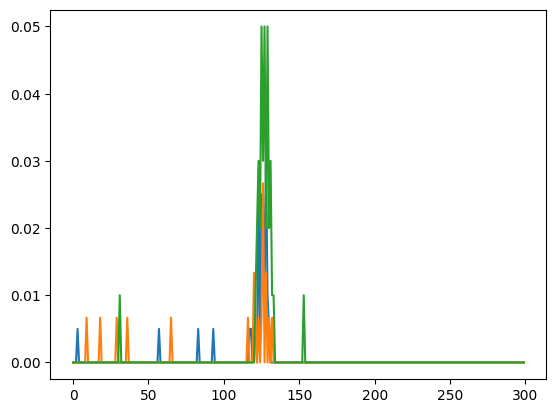

In [ ]:

plt.plot(UnitSel[UnitSel[:,0]==2, 1:].mean(axis=0), markersize=1)
plt.plot(UnitSel[UnitSel[:,0]==3, 1:].mean(axis=0), markersize=1)
plt.plot(UnitSel[UnitSel[:,0]==4, 1:].mean(axis=0), markersize=1)


plt.show()


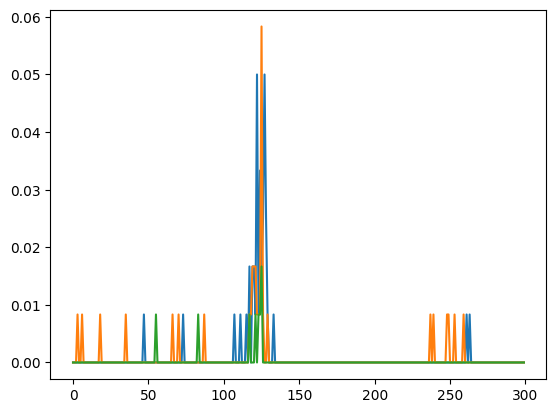

In [ ]:
plt.plot(Unit_sorted.iloc[Unit_sorted['Stim']==2, 1:].values.mean(axis=0), markersize=1)
plt.plot(Unit_sorted.iloc[Unit_sorted['Stim']==3, 1:].values.mean(axis=0), markersize=1)
plt.plot(Unit_sorted.iloc[Unit_sorted['Stim']==4, 1:].values.mean(axis=0), markersize=1)

plt.show()




array([], shape=(0, 450, 300), dtype=uint8)

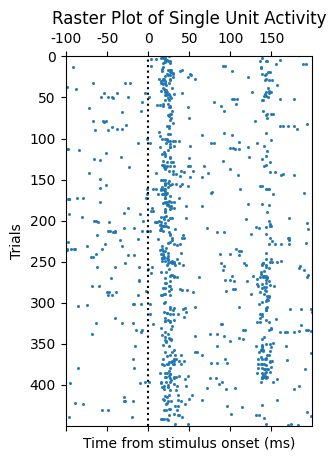

In [ ]:
plt.spy(UnitAligned, markersize=1)
plt.xlabel('Time from stimulus onset (ms)')
plt.ylabel('Trials')
plt.title('Raster Plot of Single Unit Activity')
plt.axvline(x=100, color='k', linestyle=':', label='Stimulus Onset')
plt.xticks(np.arange(0, 300, 50), labels=np.arange(-100, 200, 50))

plt.show()